# Level 1 measured SOH validation

Built with [Vicena](https://vicena.ai). This notebook uses measured calendar-aging data from six lithium-ion chemistries. Entire cell-condition trajectories are held out. This prevents measurements from one trajectory appearing in both calibration and test sets.

In [1]:
from pathlib import Path
import sys,json
sys.path.insert(0,str(Path('..')/'src'))
import matplotlib.pyplot as plt
import numpy as np
from battery_twin import load_calendar_ageing,fit_evaluate
out=Path('../outputs'); out.mkdir(exist_ok=True)
df=load_calendar_ageing('../datasets/measured/calendar_ageing')
model,m,pred,train,test=fit_evaluate(df)
print(json.dumps(m,indent=2))
print('Group leakage:',bool(set(train.cell_key)&set(test.cell_key)))
print('Chemistries:',sorted(df.chemistry.unique()))
print('Measured SOH range:',round(df.soh.min(),4),round(df.soh.max(),4))
pred.to_csv(out/'level1_predictions.csv',index=False)
(out/'level1_metrics.json').write_text(json.dumps(m,indent=2))

{
  "n_rows": 478,
  "n_groups": 108,
  "train_groups": 81,
  "test_groups": 27,
  "mae": 0.02846238817205229,
  "rmse": 0.03632376629901407,
  "r2": 0.6443601279348088,
  "baseline_mae": 0.044412429582970835
}
Group leakage: False
Chemistries: ['LCO', 'LFP', 'LMO', 'LTO', 'NCA', 'NMC']
Measured SOH range: 0.7252 1.0714


210

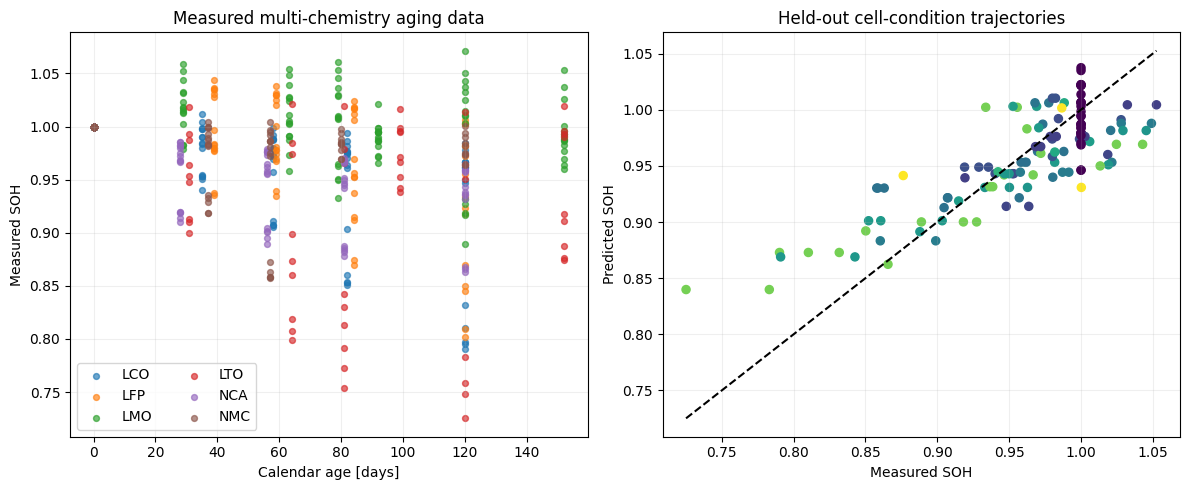

In [2]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
for c,g in df.groupby('chemistry'):
    ax[0].scatter(g.days_passed,g.soh,s=18,alpha=.65,label=c)
ax[0].set(xlabel='Calendar age [days]',ylabel='Measured SOH',title='Measured multi-chemistry aging data'); ax[0].legend(ncol=2)
ax[1].scatter(pred.soh,pred.predicted_soh,c=pred.days_passed,cmap='viridis',s=34)
lo=min(pred.soh.min(),pred.predicted_soh.min()); hi=max(pred.soh.max(),pred.predicted_soh.max()); ax[1].plot([lo,hi],[lo,hi],'--',color='black')
ax[1].set(xlabel='Measured SOH',ylabel='Predicted SOH',title='Held-out cell-condition trajectories')
for a in ax:a.grid(alpha=.2)
fig.tight_layout(); fig.savefig(out/'level1_validation.png',dpi=180); plt.show()

## Scientific boundary

This is Level 1 validation for calendar-aging SOH under the conditions represented in the dataset. The electro-thermal Level 0 model is not calibrated by these data. The result is not pack-level, online BMS, safety, or production validation. Extrapolation outside the measured chemistry, temperature, SOC, and time support requires new evidence.